# Debug: Why Does σ Level Off?

**Context:** `Demosaicing_vs_Fullfit.ipynb` shows that the direct Bayer fit precision levels off at high photon counts, particularly for the G channel. This notebook diagnoses the mechanism.

**Hypothesis:** The fitted PSF width σ stops improving above ~5,000–10,000 photons (possibly due to G1/G2 sub-lattice aliasing). Because σ and the dominant channel amplitude A are strongly coupled in the fit, the σ floor propagates directly into the colour precision floor.

**Tests implemented here:**
1. **σ precision floor** — plot std(σ_x) vs photons, compare to ideal √N scaling
2. **σ–amplitude coupling** — correlation between σ_x and each channel amplitude as a function of photon count
3. **Analytical decoupling estimate** — estimate what G precision *would* be if σ were known exactly, by removing the σ-coupled variance component
4. **χ² tail analysis** — quantify the fraction of outlier fits and whether they drive the G floor
5. **Sub-pixel proxy** — check whether a proxy for sub-pixel position (from low-noise residuals) predicts per-event G precision

**Data:** `Data/Simulation/20260320_Demosaic_vs_DirectFit/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import types
import xarray as xr
from scipy.spatial.distance import cdist

import sys
sys.path.append("../../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
from src.Multicolour_Simulation_Functions import FittingStrategy, CameraParameters, SimulationConfig
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions
plotter = PlottingFunctions.Plotter(dark_background=False)

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()


INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260330_133234.log
/tmp/ipykernel_76068/2715180176.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
data_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260320_Demosaic_vs_DirectFit"

dyes = ["ATTO 488", "ATTO 520", "ATTO 565", "ATTO 594"]
dye_colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

# Load overall summary (from Demosaicing_vs_Fullfit.ipynb)
nc_path = os.path.join(data_folder, "Demosaic_vs_DirectFit_STDEV.nc")
Overall_XR = xr.load_dataarray(nc_path)
#print("Summary array dims:", dict(Overall_XR.dims))
print("Strategies:", list(Overall_XR.coords['Strategy'].values))
print("Metrics:",    list(Overall_XR.coords['Metric'].values))

Strategies: ['Direct fit', 'Demosaic (fast)']
Metrics: ['xy', 'colour', 'B', 'G', 'R']


In [3]:
# ── Load raw HDF5 results (standard / direct Bayer fit) ──────────────────────
# Columns: xc, yc, s_x, s_y, bg_B, bg_G, bg_R, A_B, A_G, A_R,
#          chi_sqr, frame, xc_err, yc_err, s_x_err, s_y_err,
#          bg_B_err, bg_G_err, bg_R_err, A_B_err, A_G_err, A_R_err,
#          photons, background_photons, photon_level
# Note: A_B/A_G/A_R are already squared (stored in photoelectron units)
# Note: xc/yc have ground-truth subtracted (subtractx0y0=True), so xc ≈ fit error

raw = {}
for dye in dyes:
    fname = os.path.join(data_folder, f"standard_LM_method_{dye}_rawresults.h5")
    df = pd.read_hdf(fname, key='data')
    # Add normalised amplitudes
    A_sum = df['A_B'] + df['A_G'] + df['A_R']
    df['a_B'] = df['A_B'] / A_sum
    df['a_G'] = df['A_G'] / A_sum
    df['a_R'] = df['A_R'] / A_sum
    raw[dye] = df
    print(f"{dye}: {len(df):,} events, {df['photon_level'].nunique()} photon levels")

# Per-photon-level summary for each dye
def compute_per_level(df):
    """Return a DataFrame indexed by photon_level with grouped statistics."""
    grp = df.groupby('photon_level')
    out = pd.DataFrame({
        'photons':  grp['photons'].mean(),
        'sx_std':   grp['s_x'].std(),
        'sy_std':   grp['s_y'].std(),
        'aG_std':   grp['a_G'].std(),
        'aR_std':   grp['a_R'].std(),
        'aB_std':   grp['a_B'].std(),
        'chi_mean': grp['chi_sqr'].mean(),
        'chi_std':  grp['chi_sqr'].std(),
        'chi_p99':  grp['chi_sqr'].quantile(0.99),
        'n':        grp['photon_level'].count(),
    })
    return out

stats_per_level = {dye: compute_per_level(raw[dye]) for dye in dyes}
print("\nPer-level stats computed.")

ATTO 488: 20,000,000 events, 200 photon levels
ATTO 520: 20,000,000 events, 200 photon levels
ATTO 565: 20,000,000 events, 200 photon levels
ATTO 594: 20,000,000 events, 200 photon levels

Per-level stats computed.


---
## 1. The σ Precision Floor

If σ is well-determined, its precision should improve as N^−½ (shot noise limited). We test this by plotting std(σ_x) vs photon count on a log-log scale and measuring the slope at low and high photon counts.

ATTO 488      σ_x: slope (low)=-0.686  slope (high)=-0.222
ATTO 520      σ_x: slope (low)=-0.693  slope (high)=-0.250
ATTO 565      σ_x: slope (low)=-0.823  slope (high)=-0.232
ATTO 594      σ_x: slope (low)=-0.879  slope (high)=-0.152
ATTO 488      σ_y: slope (low)=-0.684  slope (high)=-0.221
ATTO 520      σ_y: slope (low)=-0.693  slope (high)=-0.253
ATTO 565      σ_y: slope (low)=-0.822  slope (high)=-0.236
ATTO 594      σ_y: slope (low)=-0.882  slope (high)=-0.151


/tmp/ipykernel_76068/2174166284.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


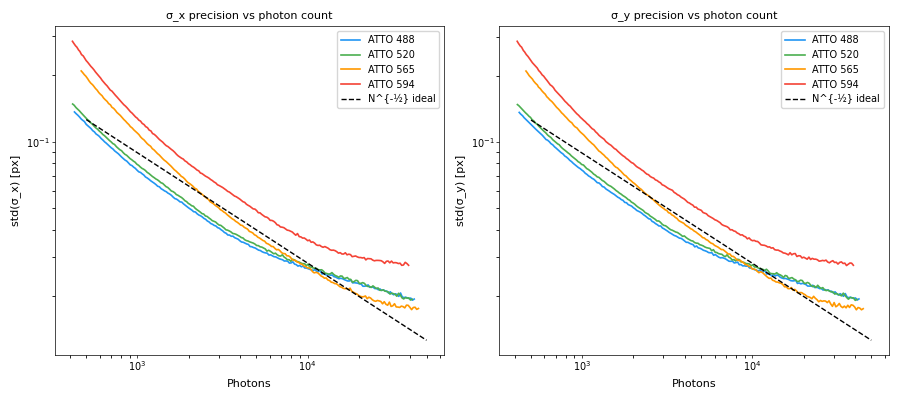


Improvement ratio std(σ_x) from ~500 to ~50 000 ph (expect 10×):
  ATTO 488: 7.0×
  ATTO 520: 7.7×
  ATTO 565: 11.9×
  ATTO 594: 10.4×


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

ideal_ref_photons = np.array([500, 50000])

for ax, sigma_col, label in zip(axes, ['sx_std', 'sy_std'], ['σ_x', 'σ_y']):
    for dye, color in zip(dyes, dye_colors):
        s = stats_per_level[dye]
        ph = s['photons'].values
        sv = s[sigma_col].values
        ax.plot(ph, sv, color=color, lw=1.2, label=dye)
        
        # Log-log slopes
        log_ph = np.log10(ph)
        log_sv = np.log10(sv)
        slope_lo, _ = np.polyfit(log_ph[:50], log_sv[:50], 1)
        slope_hi, _ = np.polyfit(log_ph[-50:], log_sv[-50:], 1)
        print(f"{dye:12s}  {label}: slope (low)={slope_lo:.3f}  slope (high)={slope_hi:.3f}")

    # Ideal -0.5 reference line (anchored to ATTO 488 at 500 ph)
    s0 = stats_per_level['ATTO 488']
    ref_y0 = s0[sigma_col].values[0]
    ref_x0 = s0['photons'].values[0]
    ax.plot(ideal_ref_photons,
            ref_y0 * (ideal_ref_photons / ref_x0) ** (-0.5),
            'k--', lw=1, label='N^{-½} ideal')
    
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Photons')
    ax.set_ylabel(f'std({label}) [px]')
    ax.set_title(f'{label} precision vs photon count')
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

# Numeric summary: improvement ratio
print("\nImprovement ratio std(σ_x) from ~500 to ~50 000 ph (expect 10×):")
for dye in dyes:
    s = stats_per_level[dye]
    ratio = s['sx_std'].iloc[0] / s['sx_std'].iloc[-1]
    print(f"  {dye}: {ratio:.1f}×")

---
## 2. σ–Amplitude Coupling

If σ and amplitude are coupled, any residual σ uncertainty will inject directly into amplitude uncertainty. We measure corr(σ_x, a_channel) per photon level. A large correlation at high photons confirms that the σ floor is responsible for the amplitude floor.

In [5]:
def coupling_vs_photons(df):
    """Return per-photon-level Pearson correlation between s_x and each normalised amplitude."""
    records = []
    for lvl, grp in df.groupby('photon_level'):
        ph = grp['photons'].mean()
        r_G = grp['s_x'].corr(grp['a_G'])
        r_R = grp['s_x'].corr(grp['a_R'])
        r_B = grp['s_x'].corr(grp['a_B'])
        records.append({'photons': ph, 'r_G': r_G, 'r_R': r_R, 'r_B': r_B})
    return pd.DataFrame(records)

print("Computing per-level correlations (may take ~30 s per dye) ...")
coupling = {dye: coupling_vs_photons(raw[dye]) for dye in dyes}
print("Done.")

Computing per-level correlations (may take ~30 s per dye) ...
Done.


/tmp/ipykernel_76068/1068140197.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


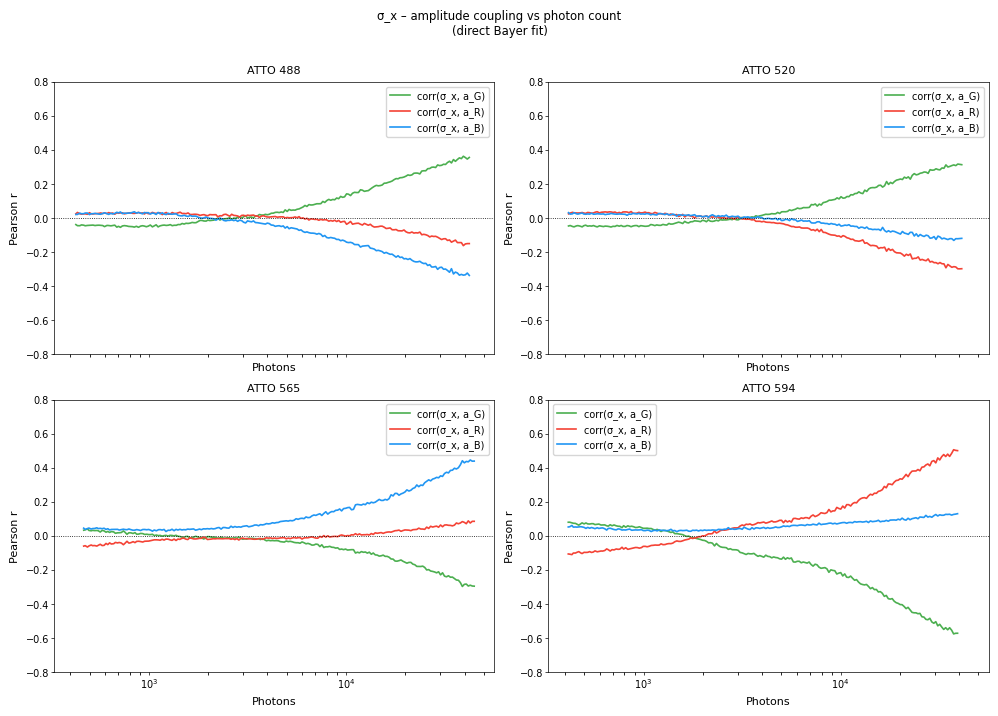

Coupling at highest photon level:
  ATTO 488      r(G)=+0.356  r(R)=-0.149  r(B)=-0.336
  ATTO 520      r(G)=+0.314  r(R)=-0.297  r(B)=-0.119
  ATTO 565      r(G)=-0.295  r(R)=+0.086  r(B)=+0.439
  ATTO 594      r(G)=-0.571  r(R)=+0.501  r(B)=+0.130


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

ch_colors = {'G': '#4CAF50', 'R': '#F44336', 'B': '#2196F3'}

for ax, dye, dye_color in zip(axes, dyes, dye_colors):
    c = coupling[dye]
    for ch in ['G', 'R', 'B']:
        ax.plot(c['photons'], c[f'r_{ch}'],
                color=ch_colors[ch], lw=1.2, label=f'corr(σ_x, a_{ch})')
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('Photons')
    ax.set_ylabel('Pearson r')
    ax.set_title(dye)
    ax.set_ylim(-0.8, 0.8)
    ax.legend(fontsize=7)

fig.suptitle('σ_x – amplitude coupling vs photon count\n(direct Bayer fit)', y=1.01)
fig.tight_layout()
plt.show()

# High-photon coupling summary
print("Coupling at highest photon level:")
for dye in dyes:
    c = coupling[dye]
    row = c.iloc[-1]
    print(f"  {dye:12s}  r(G)={row.r_G:+.3f}  r(R)={row.r_R:+.3f}  r(B)={row.r_B:+.3f}")

---
## 3. Analytical Fixed-σ Precision Estimate

If σ were known exactly and held fixed during fitting, the variance in a_G attributable to σ uncertainty would be removed. Under the linear approximation:

$$\text{Var}(a_G)_{\text{fixed-}\sigma} \approx (1 - r^2) \cdot \text{Var}(a_G)$$

where $r = \text{corr}(\sigma_x, a_G)$. This gives a floor estimate for what the STANDARD strategy *could* achieve if σ coupling were removed. We compare this to the Demosaic (fast) precision, which decouples σ from colour fitting.

/tmp/ipykernel_76068/3711062405.py:39: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


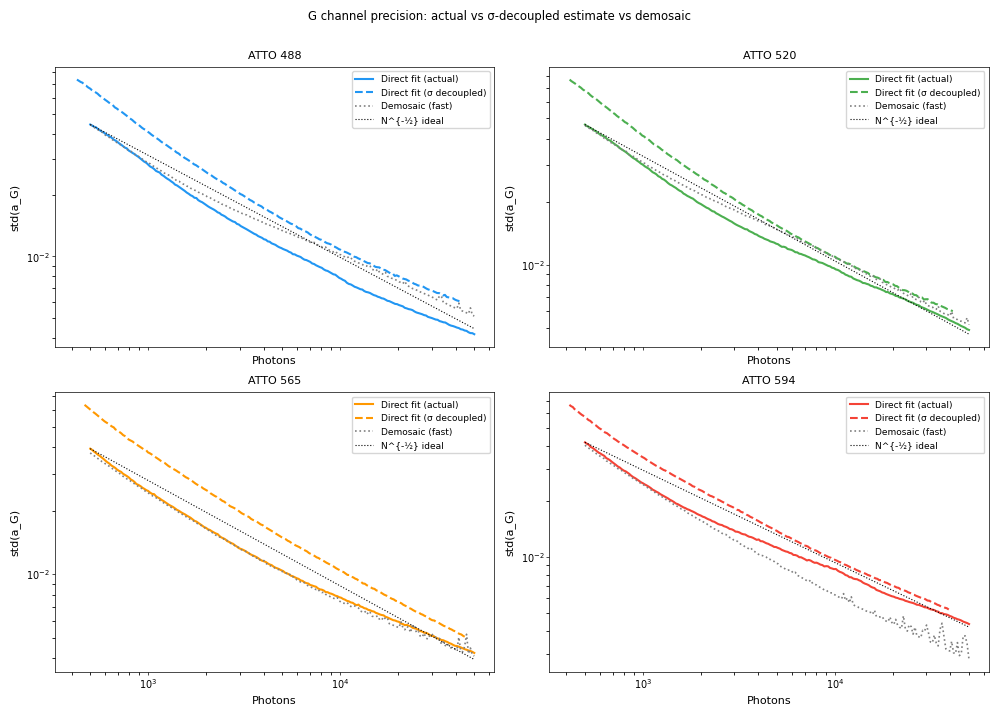

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

photon_vals = Overall_XR.coords['Photon'].values

for ax, dye, dye_color in zip(axes, dyes, dye_colors):
    s = stats_per_level[dye]
    c = coupling[dye]

    ph = s['photons'].values
    aG_std = s['aG_std'].values
    r_G = np.interp(ph, c['photons'].values, c['r_G'].values)

    # Analytical fixed-σ estimate
    aG_std_decoupled = aG_std * np.sqrt(np.clip(1 - r_G**2, 0, 1))

    # DEMOSAIC (fast) precision from NC file
    demosaic_G = Overall_XR.sel(Strategy='Demosaic (fast)', Dye=dye, Metric='G').values
    direct_G   = Overall_XR.sel(Strategy='Direct fit',     Dye=dye, Metric='G').values

    ax.plot(photon_vals, direct_G,         color=dye_color, lw=1.5, ls='-',  label='Direct fit (actual)')
    ax.plot(ph,          aG_std_decoupled, color=dye_color, lw=1.5, ls='--', label='Direct fit (σ decoupled)')
    ax.plot(photon_vals, demosaic_G,       color='grey',    lw=1.2, ls=':',  label='Demosaic (fast)')

    # Ideal √N reference
    ref_y0 = direct_G[0]
    ref_x0 = photon_vals[0]
    ax.plot([ref_x0, photon_vals[-1]],
            [ref_y0, ref_y0 * (photon_vals[-1] / ref_x0) ** (-0.5)],
            'k:', lw=0.8, label='N^{-½} ideal')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Photons')
    ax.set_ylabel('std(a_G)')
    ax.set_title(dye)
    ax.legend(fontsize=6.5)

fig.suptitle('G channel precision: actual vs σ-decoupled estimate vs demosaic', y=1.01)
fig.tight_layout()
plt.show()

**Interpretation:**
- If the σ-decoupled estimate (dashed) approaches the Demosaic (dotted), then **σ coupling alone explains the gap**.
- If the decoupled estimate still levels off, there is an **additional source of floor** (e.g., G1/G2 sub-lattice aliasing acting directly on amplitude precision).

---
## 4. χ² Tail Analysis

A well-specified model at high photons should give χ² ≈ 1 with low scatter. Fat tails (large χ²) indicate a sub-population of events with poor fits. If these outlier events drive the G precision floor, removing them should visibly improve G precision.

/tmp/ipykernel_76068/677994074.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


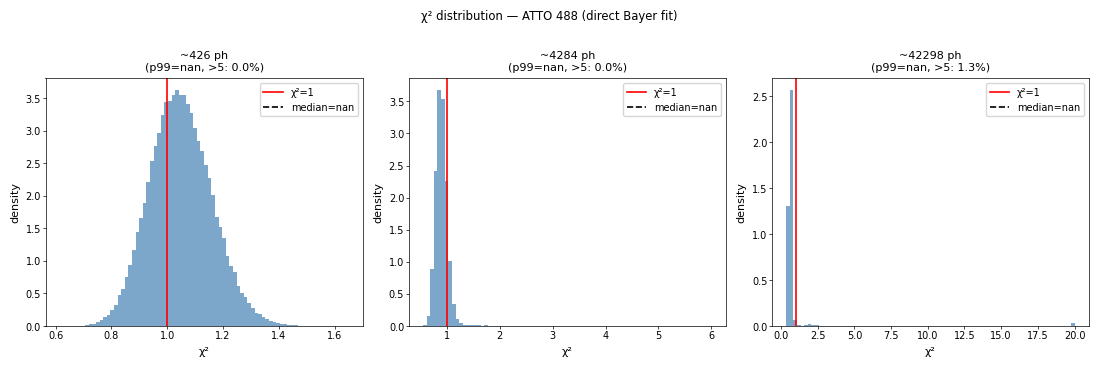

In [8]:
# ── χ² histograms at three photon levels ─────────────────────────────────────
dye_show = 'ATTO 488'  # Representative dye (G-dominant)
df = raw[dye_show]
ph_levels = sorted(df['photon_level'].unique())
ph_target_indices = [0, len(ph_levels)//2, len(ph_levels)-1]  # low / mid / high

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

for ax, lvl_idx in zip(axes, ph_target_indices):
    lvl = ph_levels[lvl_idx]
    sub = df[df['photon_level'] == lvl]
    ph_mean = sub['photons'].mean()
    chi_vals = sub['chi_sqr'].values
    chi_clip = np.clip(chi_vals, 0, 20)  # clip for display
    ax.hist(chi_clip, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(1.0, color='r', lw=1.2, label='χ²=1')
    ax.axvline(np.median(chi_vals), color='k', lw=1.2, ls='--',
               label=f'median={np.median(chi_vals):.2f}')
    frac_high = np.mean(chi_vals > 5)
    ax.set_title(f'~{ph_mean:.0f} ph\n(p99={np.percentile(chi_vals,99):.1f}, >{5:.0f}: {frac_high*100:.1f}%)')
    ax.set_xlabel('χ²')
    ax.set_ylabel('density')
    ax.legend(fontsize=7)

fig.suptitle(f'χ² distribution — {dye_show} (direct Bayer fit)', y=1.02)
fig.tight_layout()
plt.show()

/tmp/ipykernel_76068/1831440195.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tail_frac = df_d.groupby('photon_level').apply(
/tmp/ipykernel_76068/1831440195.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tail_frac = df_d.groupby('photon_level').apply(
/tmp/ipykernel_76068/1831440195.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated,

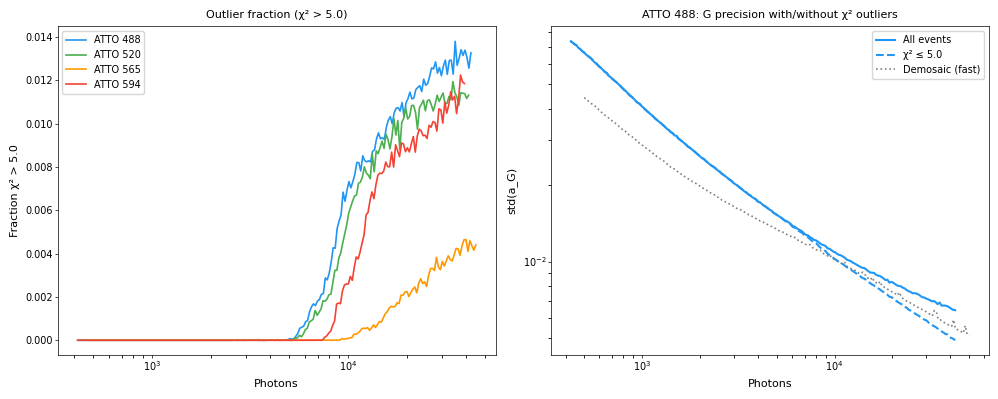

In [9]:
# ── Tail fraction vs photons, and effect of outlier removal on G std ──────────
chi_threshold = 5.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: tail fraction vs photons
ax = axes[0]
for dye, color in zip(dyes, dye_colors):
    s = stats_per_level[dye]
    df_d = raw[dye]
    tail_frac = df_d.groupby('photon_level').apply(
        lambda g: (g['chi_sqr'] > chi_threshold).mean()
    )
    ax.plot(s['photons'].values, tail_frac.values, color=color, lw=1.2, label=dye)
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel(f'Fraction χ² > {chi_threshold}')
ax.set_title(f'Outlier fraction (χ² > {chi_threshold})')
ax.legend(fontsize=7)

# Right: G std with vs without outliers (ATTO 488)
ax = axes[1]
dye_show = 'ATTO 488'
df_d = raw[dye_show]

records_all = []
records_clean = []
for lvl, grp in df_d.groupby('photon_level'):
    ph = grp['photons'].mean()
    records_all.append({'photons': ph, 'aG_std': grp['a_G'].std()})
    grp_clean = grp[grp['chi_sqr'] <= chi_threshold]
    if len(grp_clean) > 10:
        records_clean.append({'photons': ph, 'aG_std': grp_clean['a_G'].std()})

s_all   = pd.DataFrame(records_all)
s_clean = pd.DataFrame(records_clean)

ax.plot(s_all['photons'],   s_all['aG_std'],   color=dye_colors[0], lw=1.5, label='All events')
ax.plot(s_clean['photons'], s_clean['aG_std'], color=dye_colors[0], lw=1.5, ls='--', label=f'χ² ≤ {chi_threshold}')
demosaic_G = Overall_XR.sel(Strategy='Demosaic (fast)', Dye=dye_show, Metric='G').values
ax.plot(photon_vals, demosaic_G, color='grey', lw=1.2, ls=':', label='Demosaic (fast)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('std(a_G)')
ax.set_title(f'{dye_show}: G precision with/without χ² outliers')
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

### 4b. Weight Miscalibration: Why Does the Median χ² Fall Below 1?

The bulk of fits have χ² < 1 at high photons. This is a separate issue from the χ² > 5 tail: it means the fitting *weights* (σ²_pixel computed from the smoothed data) systematically **overestimate** the true noise variance.

**Mechanism:** The smoothing kernel (σ_smooth = 1.5 px) spreads PSF signal from bright peak pixels into the surrounding flank pixels. Flank pixels therefore get a smoothed-signal value *larger* than their true signal, inflating their variance estimate and reducing their weight. Since there are many flank/background pixels and they carry high weight (low signal → tight constraint), this overestimation dominates the χ² sum and pushes it below 1.

The effect is proportional to signal level — it worsens with increasing photon count — which explains the monotonic χ² decrease with photons.

**Fix:** Replace the smoothing-based variance with a **model-based variance**: after fitting, recompute weights as `σ²_i = model_signal_i / gain + readnoise²` and re-evaluate χ². This is a post-processing step (no re-fit needed) and should restore the median χ² to ≈ 1.

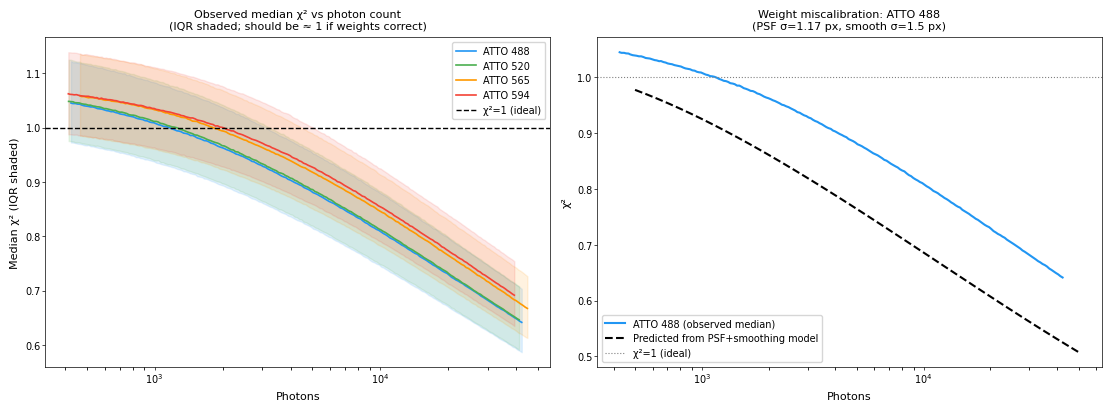

PSF σ used for prediction: 1.167 px
Predicted chi_sqr at 500 ph:    0.978
Predicted chi_sqr at 50000 ph:  0.508
Observed  chi_sqr at ~50000 ph: 0.642


In [10]:
# ── 4b: Weight miscalibration — median chi_sqr vs photons ────────────────────
# Panel 1: Observed median chi_sqr vs photons for all dyes
# Panel 2: Predicted chi_sqr from synthetic PSF + smoothing model,
#          overlaid on ATTO 488 observations

from scipy.ndimage import gaussian_filter
import sys
sys.path.insert(0, '../../..')
from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

# Simulation / fitting constants (match Demosaicing_vs_Fullfit config)
image_size  = 14
sigma_smooth = 1.5   # Gaussian smoothing sigma applied before fitting [px]
gain        = 2.0    # sCMOS gain [e-/ADU] — used only for readnoise scaling
readnoise_e = 1.5    # sCMOS readnoise [e-]
DOF         = image_size**2 - 10  # 186

# ── Observed median chi_sqr per photon level ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
chi_medians = {}
for dye, color in zip(dyes, dye_colors):
    grp = raw[dye].dropna(subset=['chi_sqr']).groupby('photon_level')
    chi_med = grp['chi_sqr'].median()
    chi_q25 = grp['chi_sqr'].quantile(0.25)
    chi_q75 = grp['chi_sqr'].quantile(0.75)
    ph_mean = grp['photons'].mean()
    ax.plot(ph_mean.values, chi_med.values, color=color, lw=1.2, label=dye)
    ax.fill_between(ph_mean.values, chi_q25.values, chi_q75.values,
                    color=color, alpha=0.12)
    chi_medians[dye] = (ph_mean.values, chi_med.values)

ax.axhline(1.0, color='k', lw=1, ls='--', label='χ²=1 (ideal)')
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('Median χ² (IQR shaded)')
ax.set_title('Observed median χ² vs photon count\n(IQR shaded; should be ≈ 1 if weights correct)')
ax.legend(fontsize=7)

# ── Predicted chi_sqr from PSF + smoothing geometry ──────────────────────────
# For a Gaussian PSF of width sigma_psf smoothed with sigma_smooth:
#   E[chi_sqr] = (1/DOF) × Σ_i  signal_i / smooth_signal_i
# (shot-noise limit; background pixels contribute ≈ 1 each via readnoise)
#
# We sweep over PSF sigma values (one per dye, taken from the fitted s_x mean)
# and photon counts, then overlay on the ATTO 488 observation.

masks_3d = M_F.get_masks(size_x=image_size, size_y=image_size)  # (14,14,3)
x_pix = np.arange(image_size, dtype=float)
X, Y  = np.meshgrid(x_pix, x_pix, indexing='ij')
center = (image_size - 1) / 2.0  # 6.5

dye_show = 'ATTO 488'
sigma_psf = stats_per_level[dye_show]['sx_std'].mean() + \
            raw[dye_show].dropna(subset=['s_x'])['s_x'].mean()
# Use the mean fitted sigma for this dye
sigma_psf = raw[dye_show].dropna(subset=['s_x'])['s_x'].mean()

# Build normalised 2D Gaussian PSF image (dimensionless, sums to 1 over pixels)
norm2d = 1.0 / (2 * np.pi * sigma_psf**2)
psf_img = norm2d * np.exp(-0.5 * ((X - center)**2 + (Y - center)**2) / sigma_psf**2)
psf_img /= psf_img.sum()          # ensure sums to 1

smooth_psf = gaussian_filter(psf_img, sigma=sigma_smooth)

predicted_chi_photons = []
predicted_chi_vals    = []

ph_range = np.logspace(np.log10(500), np.log10(50000), 40)
for n_ph in ph_range:
    # Bayer-patterned signal image (R=ch0, G=ch1, B=ch2 via pixel_QYs ≈ 1)
    # Approximate: signal_i = n_ph × a_G × psf_img for G pixels, etc.
    # For weight miscalibration the channel split doesn't matter — use total signal
    signal  = n_ph * psf_img                  # total photoelectrons per pixel
    smoothed = n_ph * smooth_psf              # smoothed estimate

    var_true   = signal   / gain + readnoise_e**2
    var_smooth = np.maximum(smoothed, 0) / gain + readnoise_e**2

    E_chi = np.sum(var_true / var_smooth) / DOF
    predicted_chi_photons.append(n_ph)
    predicted_chi_vals.append(E_chi)

ax = axes[1]
ph_obs, chi_obs = chi_medians[dye_show]
ax.plot(ph_obs, chi_obs, color=dye_colors[0], lw=1.5, label=f'{dye_show} (observed median)')
ax.plot(predicted_chi_photons, predicted_chi_vals,
        color='k', lw=1.5, ls='--', label='Predicted from PSF+smoothing model')
ax.axhline(1.0, color='grey', lw=0.8, ls=':', label='χ²=1 (ideal)')
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('χ²')
ax.set_title(f'Weight miscalibration: {dye_show}\n'
             f'(PSF σ={sigma_psf:.2f} px, smooth σ={sigma_smooth} px)')
ax.legend(fontsize=7)

plt.show()

print(f"PSF σ used for prediction: {sigma_psf:.3f} px")
print(f"Predicted chi_sqr at 500 ph:    {np.interp(500, predicted_chi_photons, predicted_chi_vals):.3f}")
print(f"Predicted chi_sqr at 50000 ph:  {np.interp(50000, predicted_chi_photons, predicted_chi_vals):.3f}")
print(f"Observed  chi_sqr at ~50000 ph: {chi_obs[-1]:.3f}")

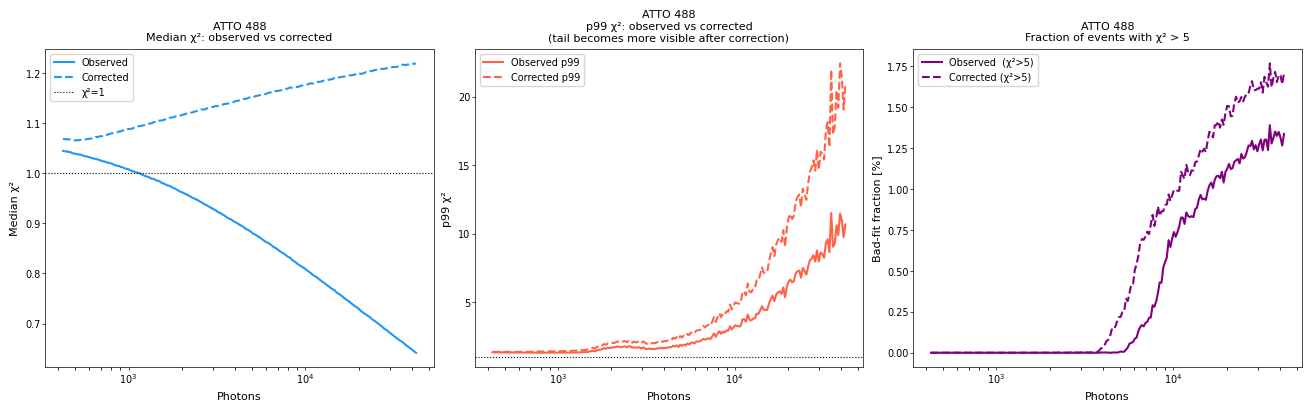

Correction summary at selected photon levels:
  ~Photons   E_factor   chi_med_obs   chi_med_corr   bad_obs%   bad_corr%
       992      0.927         1.009          1.089       0.00        0.00
      5037      0.764         0.880          1.152       0.01        0.22
     10084      0.685         0.808          1.178       0.74        1.00
     24853      0.583         0.704          1.207       1.19        1.54
     42298      0.526         0.642          1.220       1.34        1.71


In [11]:
# ── 4c: Apply weight-recalibration correction to observed chi_sqr ─────────────
#
# The correction factor E_factor(n_ph) = Σ_i signal_i/smooth_i / DOF was computed
# in 4b (predicted_chi_vals / predicted_chi_photons).  Analytically:
#
#   E[chi_sqr_observed]   = E_factor          (smoothing-based weights)
#   E[chi_sqr_corrected]  = 1                 (model-based weights)
#   => chi_sqr_corrected  = chi_sqr_observed / E_factor
#
# E_factor depends only on photon count (via PSF signal level), so we interpolate
# it to the mean photon count at each bootstrap level and apply per-event.
# No raw images required.

dye_show = 'ATTO 488'
df_d = raw[dye_show].dropna(subset=['chi_sqr']).copy()

# Interpolate E_factor to each event's photon count
df_d['E_factor'] = np.interp(
    df_d['photons'].values,
    predicted_chi_photons,
    predicted_chi_vals,
    left=predicted_chi_vals[0],
    right=predicted_chi_vals[-1],
)
df_d['chi_sqr_corrected'] = df_d['chi_sqr'] / df_d['E_factor']

# Per-level summaries
grp = df_d.groupby('photon_level')
ph_mean       = grp['photons'].mean()
chi_obs_med   = grp['chi_sqr'].median()
chi_corr_med  = grp['chi_sqr_corrected'].median()
chi_obs_p99   = grp['chi_sqr'].quantile(0.99)
chi_corr_p99  = grp['chi_sqr_corrected'].quantile(0.99)
frac_bad_obs  = grp['chi_sqr'].apply(lambda x: (x > 5).mean())
frac_bad_corr = grp['chi_sqr_corrected'].apply(lambda x: (x > 5).mean())

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

# Panel 1: median chi_sqr before and after correction
ax = axes[0]
ax.plot(ph_mean.values, chi_obs_med.values,  color=dye_colors[0], lw=1.5, label='Observed')
ax.plot(ph_mean.values, chi_corr_med.values, color=dye_colors[0], lw=1.5, ls='--', label='Corrected')
ax.axhline(1.0, color='k', lw=0.8, ls=':', label='χ²=1')
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('Median χ²')
ax.set_title(f'{dye_show}\nMedian χ²: observed vs corrected')
ax.legend(fontsize=7)

# Panel 2: p99 before and after correction
ax = axes[1]
ax.plot(ph_mean.values, chi_obs_p99.values,  color='tomato',      lw=1.5, label='Observed p99')
ax.plot(ph_mean.values, chi_corr_p99.values, color='tomato',      lw=1.5, ls='--', label='Corrected p99')
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('p99 χ²')
ax.set_title(f'{dye_show}\np99 χ²: observed vs corrected\n(tail becomes more visible after correction)')
ax.legend(fontsize=7)

# Panel 3: bad-fit fraction (chi > 5) before and after correction
ax = axes[2]
ax.plot(ph_mean.values, frac_bad_obs.values * 100,  color='purple', lw=1.5, label='Observed  (χ²>5)')
ax.plot(ph_mean.values, frac_bad_corr.values * 100, color='purple', lw=1.5, ls='--', label='Corrected (χ²>5)')
ax.set_xscale('log')
ax.set_xlabel('Photons')
ax.set_ylabel('Bad-fit fraction [%]')
ax.set_title(f'{dye_show}\nFraction of events with χ² > 5')
ax.legend(fontsize=7)

plt.show()

# Summary table
print("Correction summary at selected photon levels:")
print(f"{'~Photons':>10}  {'E_factor':>9}  {'chi_med_obs':>12}  {'chi_med_corr':>13}  {'bad_obs%':>9}  {'bad_corr%':>10}")
for ph_target in [1000, 5000, 10000, 25000, 50000]:
    idx = (ph_mean - ph_target).abs().idxmin()
    ef  = df_d[df_d['photon_level'] == idx]['E_factor'].mean()
    print(f"{ph_mean[idx]:>10.0f}  {ef:>9.3f}  {chi_obs_med[idx]:>12.3f}  {chi_corr_med[idx]:>13.3f}  "
          f"{frac_bad_obs[idx]*100:>9.2f}  {frac_bad_corr[idx]*100:>10.2f}")

**Interpretation:**
- If removing high-χ² events substantially improves G precision: the outlier sub-population (likely events where the PSF centre straddles the G1/G2 boundary) drives the floor.
- If the floor persists after outlier removal: the levelling-off is a property of the *typical* event, not just the tail.

---
## 5. Sub-pixel Position Proxy

The G sub-lattice aliasing should be worst when the PSF centre is exactly midway between the two G sub-lattices (at a fractional pixel offset of 0.5 within the 2-pixel Bayer period). We can probe this using the **fitted xc at the highest photon level** as a proxy for the true sub-pixel position (the fit error is ~0.01 px at 50,000 ph, so xc ≈ true position modulo any global offset).

**Caveat:** `subtractx0y0=True` was used when generating the data, so the stored `xc` is (fitted − true), not the absolute position. The true sub-pixel position is lost for this dataset. The analysis below instead uses the **fitted-minus-true residuals** to check whether there is a consistent *direction* of position bias that correlates with G precision. A new simulation with `subtractx0y0=False` would be needed for the full test (see Section 6).

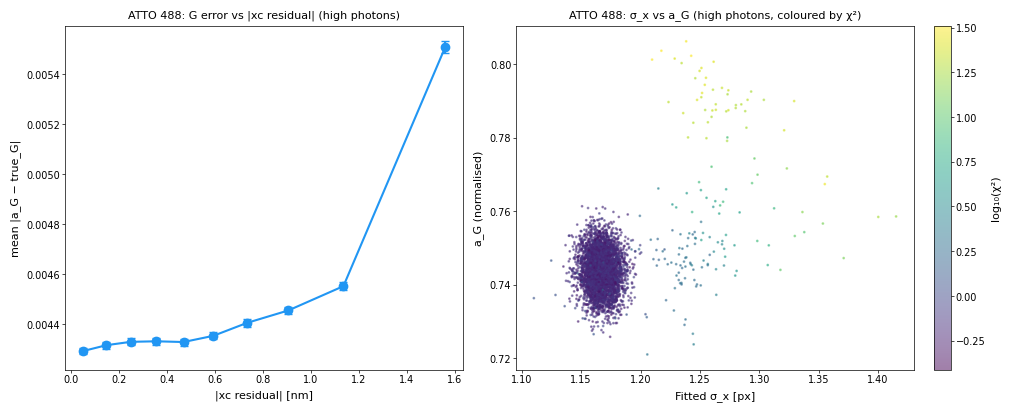

corr(|xc|, |aG_err|) at high photons: 0.0825
corr(s_x, a_G) at high photons:        0.3468
corr(chi_sqr, |aG_err|) at high photons: 0.7331


In [12]:
# ── Check whether |xc_residual| predicts per-event G error ───────────────────
# At high photon levels, bin events by |xc| residual and plot mean |a_G - true_G|

dye_show = 'ATTO 488'
df_d = raw[dye_show]
ph_levels = sorted(df_d['photon_level'].unique())

# Use top 10 photon levels
hi_levels = ph_levels[-10:]
sub = df_d[df_d['photon_level'].isin(hi_levels)].copy()

# True G fraction (mean at high photons ≈ ground truth)
true_aG = sub['a_G'].mean()
sub['aG_err'] = np.abs(sub['a_G'] - true_aG)
sub['xc_abs'] = np.abs(sub['xc'])  # absolute position residual

# Quantile-based binning — robust to duplicate bin edges
sub['xc_bin'] = pd.qcut(sub['xc_abs'], q=10, duplicates='drop')
binned = sub.groupby('xc_bin', observed=True).agg(
    xc_mid=('xc_abs', 'median'),
    aG_err_mean=('aG_err', 'mean'),
    aG_err_std=('aG_err', 'std'),
    n=('xc_abs', 'count')
).dropna()

# constrained_layout avoids conflict with colorbar layout engine
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
ax.errorbar(binned['xc_mid'] * 69, binned['aG_err_mean'],
            yerr=binned['aG_err_std'] / np.sqrt(binned['n']),
            fmt='o-', color=dye_colors[0], capsize=3)
ax.set_xlabel('|xc residual| [nm]')
ax.set_ylabel('mean |a_G − true_G|')
ax.set_title(f'{dye_show}: G error vs |xc residual| (high photons)')

# Scatter: s_x vs a_G (coupling scatter plot)
ax = axes[1]
sample = sub.sample(min(5000, len(sub)), random_state=42)
sc = ax.scatter(sample['s_x'], sample['a_G'],
                c=np.log10(sample['chi_sqr'] + 0.01),
                s=1, cmap='viridis', alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label='log₁₀(χ²)')
ax.set_xlabel('Fitted σ_x [px]')
ax.set_ylabel('a_G (normalised)')
ax.set_title(f'{dye_show}: σ_x vs a_G (high photons, coloured by χ²)')

plt.show()

# Correlation at high photons
print(f"corr(|xc|, |aG_err|) at high photons: {sub['xc_abs'].corr(sub['aG_err']):.4f}")
print(f"corr(s_x, a_G) at high photons:        {sub['s_x'].corr(sub['a_G']):.4f}")
print(f"corr(chi_sqr, |aG_err|) at high photons: {sub['chi_sqr'].corr(sub['aG_err']):.4f}")

---
## 6. Summary: Log-Log Scaling Slopes

Tabulate the scaling exponent (slope on a log-log photons vs precision plot) for each channel and dye, at low and high photon counts. The ideal shot-noise-limited exponent is −0.5.

In [13]:
rows = []
for dye in dyes:
    s = stats_per_level[dye]
    log_ph = np.log10(s['photons'].values)
    for ch, col in [('G', 'aG_std'), ('R', 'aR_std'), ('B', 'aB_std'), ('σ_x', 'sx_std')]:
        log_v = np.log10(s[col].values)
        slope_lo, _ = np.polyfit(log_ph[:50],  log_v[:50],  1)
        slope_hi, _ = np.polyfit(log_ph[-50:], log_v[-50:], 1)
        rows.append({'Dye': dye, 'Channel': ch,
                     'slope_low': slope_lo, 'slope_high': slope_hi,
                     'improvement': s[col].iloc[0] / s[col].iloc[-1]})

slope_df = pd.DataFrame(rows)
slope_df['slope_low']  = slope_df['slope_low'].round(3)
slope_df['slope_high'] = slope_df['slope_high'].round(3)
slope_df['improvement'] = slope_df['improvement'].round(1)

# Pivot for readability
pivot_hi = slope_df.pivot(index='Dye', columns='Channel', values='slope_high')
print("High-photon log-log slope (ideal = −0.50):")
print(pivot_hi.to_string())
print()
pivot_imp = slope_df.pivot(index='Dye', columns='Channel', values='improvement')
print("Improvement ratio 500→50 000 ph (ideal = 10×):")
print(pivot_imp.to_string())

High-photon log-log slope (ideal = −0.50):
Channel       B      G      R    σ_x
Dye                                 
ATTO 488 -0.387 -0.348 -0.448 -0.222
ATTO 520 -0.447 -0.375 -0.410 -0.250
ATTO 565 -0.407 -0.441 -0.494 -0.232
ATTO 594 -0.558 -0.301 -0.340 -0.152

Improvement ratio 500→50 000 ph (ideal = 10×):
Channel      B     G     R   σ_x
Dye                             
ATTO 488  12.4  11.4  14.6   7.0
ATTO 520  14.6  12.1  12.9   7.7
ATTO 565  16.9  12.1  13.5  11.9
ATTO 594  20.5  10.6  12.0  10.4


---
## ⚠️ TEST: 2-Stage IRLS Fitting

**Status:** proof-of-concept — to be ported to `ImageAnalysisFunctions.StandardFittingProcessor` if successful.

**Hypothesis:** Replacing the fixed smoothing-based weights with **model-based weights** (updated from the stage-1 fitted model) will:
1. Return the median χ² to ≈ 1.
2. Reduce the fraction of bad fits (inflated σ, high χ²) caused by G1/G2 sub-lattice aliasing.
3. Improve A_G precision at high photon counts.

**Method (Iteratively Reweighted Least Squares, 2 stages):**
- **Stage 1:** LM fit with smoothing-based weights (existing approach) → stable convergence, provides initial model.
- **Stage 2:** Recompute weights as `w_i = 1 / (model₁_i / gain + σ²_read)` → re-run LM from stage-1 solution (warm start).

No raw images are needed — synthetic Bayer images are generated from known Gaussian PSF parameters with Poisson + readnoise.  Spectral fractions and PSF width match ATTO 488 at the values recovered from the simulation data.

In [14]:
# ── TEST: 2-Stage IRLS — synthetic Monte Carlo ───────────────────────────────
# Stage 1:  smooth-based weights        (basin finding)
# Stage 2:  model weights from Stage 1  (first IRLS update)
# Stage 3:  model weights from Stage 2  (second IRLS update)
#
# Unit convention: data and model are in PHOTOELECTRONS (pe).
# Weight formula matches production _compute_error_maps / generate_weights:
#   w = 1 / (max(signal_pe, 0) + 1 + readnoise_e²)
# The camera gain is used only for ADU→pe conversion, which is upstream of
# fitting.  By the time WLS sees the data it is already in pe, so gain = 1.

from scipy.ndimage import gaussian_filter
from scipy.optimize import leastsq
import sys
sys.path.insert(0, '../../..')
from src import gaussoptfuncs, MaskFunctions as MF_mod

image_size   = 14
sigma_smooth = 1.5
readnoise_e  = 1.5    # e-  (from camera calibration)
DOF          = image_size**2 - 10

true_sigma   = raw['ATTO 488'].dropna(subset=['s_x'])['s_x'].mean()
true_aB, true_aG, true_aR = 0.155, 0.744, 0.101
true_bg      = 5.0    # pe per pixel per channel
center       = (image_size - 1) / 2.0

_mask_dict = MF_mod.Mask_Functions().get_masks(size_x=image_size, size_y=image_size)
masks_f32  = np.dstack([_mask_dict[k] for k in _mask_dict.keys()]).astype(np.float32)
masks_bool = masks_f32.astype(bool)
x_arr      = np.arange(image_size, dtype=np.float32)

N_trials           = 1000
photon_levels_test = [5000, 10000, 25000, 50000]

store = {ph: {k: [] for k in ('chi1', 'chi2', 'chi3',
                                'sx1',  'sx2',  'sx3',
                                'aG1',  'aG2',  'aG3')}
         for ph in photon_levels_test}

def prod_weights(signal_pe, readnoise):
    """Production weight formula: 1 / (max(signal,0) + 1 + readnoise²)
    Matches Multicolour_Simulation_Functions._compute_error_maps and
    IOFunctions.generate_weights exactly."""
    e = np.maximum(signal_pe, 0).astype(np.float32) + 1.0 + readnoise**2
    return (1.0 / e).astype(np.float32)

def model_weights(pfit, masks, x_arr, size, readnoise):
    buf = np.zeros((size, size), dtype=np.float32)
    mdl = gaussoptfuncs.WLS_model_nobounds(pfit.astype(np.float32), masks, x_arr, buf)
    return prod_weights(mdl, readnoise)

def do_fit(x0, data, masks, weights, size):
    pfit, _, _, _, ok = leastsq(
        gaussoptfuncs.WLS_chi_nobounds, x0=x0,
        args=(data, masks, weights, size, size**2),
        full_output=True, ftol=1e-6, xtol=1e-6)
    return pfit, ok

def chi_sqr(pfit, data, masks, weights, size, dof):
    r = gaussoptfuncs.WLS_chi_nobounds(
        pfit.astype(np.float32), data, masks, weights, size, size**2)
    return float(np.sum(r**2)) / dof

def a_frac(p, idx):
    total = p[7]**2 + p[8]**2 + p[9]**2
    return p[idx]**2 / total if total > 0 else np.nan

rng = np.random.default_rng(42)
print(f"Running {N_trials} trials × {len(photon_levels_test)} photon levels × 3 IRLS stages ...")
print(f"Weight formula: 1/(max(signal,0) + 1 + {readnoise_e}²)  [production-matched]\n")

for n_ph in photon_levels_test:
    A_B_true = true_aB * n_ph
    A_G_true = true_aG * n_ph
    A_R_true = true_aR * n_ph

    for _ in range(N_trials):
        dx, dy = rng.uniform(-0.5, 0.5), rng.uniform(-0.5, 0.5)

        params_true = np.array([
            center+dx, center+dy, true_sigma, true_sigma,
            np.sqrt(true_bg), np.sqrt(true_bg), np.sqrt(true_bg),
            np.sqrt(A_B_true), np.sqrt(A_G_true), np.sqrt(A_R_true),
        ], dtype=np.float32)

        buf0    = np.zeros((image_size, image_size), dtype=np.float32)
        model_t = gaussoptfuncs.WLS_model_nobounds(params_true, masks_f32, x_arr, buf0).copy()
        data    = (rng.poisson(np.maximum(model_t, 0)).astype(np.float32)
                   + rng.standard_normal(model_t.shape).astype(np.float32) * readnoise_e)

        # Stage 1: smoothing weights (production formula)
        smooth = gaussian_filter(data, sigma=sigma_smooth)
        w1     = prod_weights(smooth, readnoise_e)
        ig     = np.array(gaussoptfuncs.initial_guess(
                      smooth.astype(np.float32), data.astype(np.float32), masks_bool), dtype=np.float64)
        pfit1, ok1 = do_fit(ig, data, masks_f32, w1, image_size)
        if ok1 not in (1, 2, 3, 4):
            continue

        # Stage 2: model weights from Stage 1
        w2         = model_weights(pfit1, masks_f32, x_arr, image_size, readnoise_e)
        pfit2, ok2 = do_fit(pfit1, data, masks_f32, w2, image_size)
        if ok2 not in (1, 2, 3, 4):
            continue

        # Stage 3: model weights from Stage 2
        w3         = model_weights(pfit2, masks_f32, x_arr, image_size, readnoise_e)
        pfit3, ok3 = do_fit(pfit2, data, masks_f32, w3, image_size)
        if ok3 not in (1, 2, 3, 4):
            continue

        store[n_ph]['chi1'].append(chi_sqr(pfit1, data, masks_f32, w1, image_size, DOF))
        store[n_ph]['chi2'].append(chi_sqr(pfit2, data, masks_f32, w2, image_size, DOF))
        store[n_ph]['chi3'].append(chi_sqr(pfit3, data, masks_f32, w3, image_size, DOF))
        store[n_ph]['sx1'].append(abs(float(pfit1[3])));  store[n_ph]['sx2'].append(abs(float(pfit2[3]))); store[n_ph]['sx3'].append(abs(float(pfit3[3])))
        store[n_ph]['aG1'].append(a_frac(pfit1, 8));      store[n_ph]['aG2'].append(a_frac(pfit2, 8));     store[n_ph]['aG3'].append(a_frac(pfit3, 8))

    c1, c2, c3 = (np.array(store[n_ph][k]) for k in ('chi1', 'chi2', 'chi3'))
    print(f"  {n_ph:6d} ph  chi: S1={np.median(c1):.3f}  S2={np.median(c2):.3f}  S3={np.median(c3):.3f}  "
          f"| bad>5: S1={np.mean(c1>5)*100:.1f}%  S2={np.mean(c2>5)*100:.1f}%  S3={np.mean(c3>5)*100:.1f}%")

print(f"\nTrue sigma: {true_sigma:.4f} px")


Running 1000 trials × 4 photon levels × 3 IRLS stages ...
Weight formula: 1/(max(signal,0) + 1 + 1.5²)  [production-matched]

    5000 ph  chi: S1=0.736  S2=0.894  S3=0.887  | bad>5: S1=0.0%  S2=0.0%  S3=0.0%
   10000 ph  chi: S1=0.682  S2=0.898  S3=0.890  | bad>5: S1=0.0%  S2=0.0%  S3=0.0%
   25000 ph  chi: S1=0.592  S2=0.901  S3=0.894  | bad>5: S1=0.0%  S2=0.0%  S3=0.0%
   50000 ph  chi: S1=0.526  S2=0.909  S3=0.902  | bad>5: S1=0.0%  S2=0.0%  S3=0.0%

True sigma: 1.1671 px



 Photons    medχ² S1    medχ² S2    medχ² S3    std(σ)S1    std(σ)S2    std(σ)S3
--------------------------------------------------------------------------------
    5000       0.736       0.894       0.887       26.69       22.18       22.17
   10000       0.682       0.898       0.890       18.66       15.15       15.13
   25000       0.592       0.901       0.894       10.93        8.75        8.76
   50000       0.526       0.909       0.902        7.86        5.88        5.88


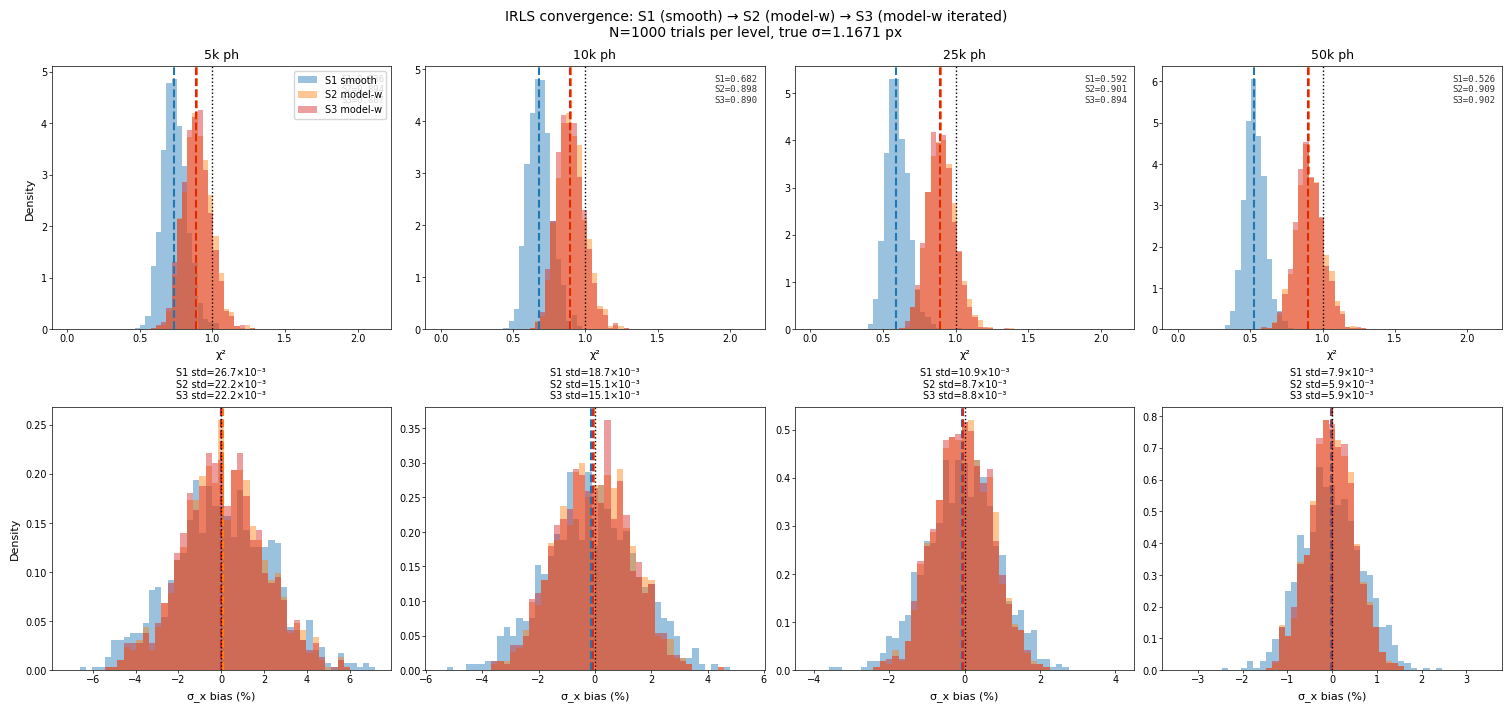

In [15]:
# ── TEST: IRLS results — visualisation ───────────────────────────────────────
variants = {
    'S1 smooth':  ('chi1', 'sx1', 'aG1', '#1f77b4'),
    'S2 model-w': ('chi2', 'sx2', 'aG2', '#ff7f0e'),
    'S3 model-w': ('chi3', 'sx3', 'aG3', '#d62728'),
}

fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)

for col, n_ph in enumerate(photon_levels_test):
    d = store[n_ph]

    # ── Row 0: χ² distribution ───────────────────────────────────────────────
    ax = axes[0, col]
    all_chi = np.concatenate([np.array(d[ck]) for ck, sk, ak, c_ in variants.values()])
    chi_max = min(15, np.nanpercentile(all_chi, 99) + 1)
    bins    = np.linspace(0, chi_max, 60)
    for label, (ck, sk, ak, c_) in variants.items():
        arr = np.array(d[ck])
        ax.hist(arr, bins=bins, alpha=0.45, color=c_, label=label, density=True)
        ax.axvline(np.median(arr), color=c_, lw=1.5, ls='--')
    ax.axvline(1.0, color='k', lw=1, ls=':')
    ax.set_title(f'{n_ph//1000}k ph', fontsize=9)
    ax.set_xlabel('χ²', fontsize=8)
    if col == 0:
        ax.set_ylabel('Density', fontsize=8)
        ax.legend(fontsize=7)
    meds = [f"{label.split()[0]}={np.median(np.array(d[ck])):.3f}"
            for label, (ck, sk, ak, c_) in variants.items()]
    ax.text(0.98, 0.97, '\n'.join(meds), transform=ax.transAxes,
            fontsize=6.5, ha='right', va='top', color='#333333', family='monospace')

    # ── Row 1: σ_x bias ──────────────────────────────────────────────────────
    ax2 = axes[1, col]
    all_bias = np.concatenate([(np.array(d[sk]) - true_sigma) / true_sigma * 100
                                for ck, sk, ak, c_ in variants.values()])
    blim  = min(30, np.nanpercentile(np.abs(all_bias), 99) + 2)
    bbins = np.linspace(-blim, blim, 50)
    for label, (ck, sk, ak, c_) in variants.items():
        bias = (np.array(d[sk]) - true_sigma) / true_sigma * 100
        ax2.hist(bias, bins=bbins, alpha=0.45, color=c_, label=label, density=True)
        ax2.axvline(np.median(bias), color=c_, lw=1.5, ls='--')
    ax2.axvline(0, color='k', lw=1, ls=':')
    ax2.set_xlabel('σ_x bias (%)', fontsize=8)
    if col == 0:
        ax2.set_ylabel('Density', fontsize=8)
    stds = [f"{label.split()[0]} std={np.std(np.array(d[sk]))*1e3:.1f}×10⁻³"
            for label, (ck, sk, ak, c_) in variants.items()]
    ax2.set_title('\n'.join(stds), fontsize=7)

fig.suptitle('IRLS convergence: S1 (smooth) → S2 (model-w) → S3 (model-w iterated)\n'
             f'N={N_trials} trials per level, true σ={true_sigma:.4f} px', fontsize=10)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Photons':>8}  {'medχ² S1':>10}  {'medχ² S2':>10}  {'medχ² S3':>10}  "
      f"{'std(σ)S1':>10}  {'std(σ)S2':>10}  {'std(σ)S3':>10}")
print('-' * 80)
for n_ph in photon_levels_test:
    d = store[n_ph]
    c1,c2,c3   = (np.array(d[k]) for k in ('chi1','chi2','chi3'))
    s1,s2,s3   = (np.array(d[k]) for k in ('sx1', 'sx2', 'sx3'))
    print(f"{n_ph:>8}  {np.median(c1):>10.3f}  {np.median(c2):>10.3f}  {np.median(c3):>10.3f}  "
          f"{np.std(s1)*1e3:>10.2f}  {np.std(s2)*1e3:>10.2f}  {np.std(s3)*1e3:>10.2f}")

plt.show()


---
## 7. Future Test: Fixed-σ Re-simulation

**Goal (Test 2 from `claude/Fit_levelling_off.md`):** Re-run the bootstrap simulation with σ_x and σ_y held fixed at their true values. Only xc, yc, A_B, A_G, A_R, bg_B, bg_G, bg_R are free parameters.

**Implementation note:** The existing `FittingStrategy.RAWCOLOUR` strategy (`ImageAnalysisFunctions.py`, `JustColourFittingProcessor` + `RawColourFittingProcessor`) already implements colour-only fitting with position/sigma fixed from a prior estimate. The two-stage pipeline (`PosthenColourFittingProcessor`) fits a grayscale Gaussian first, then fixes position/sigma for the colour fit — this is the closest existing mechanism.

Alternatively: add a `WLS_chi_fixedsigma_nobounds` cost function to `gaussoptfuncs.py` that fixes params[2] and params[3] (σ_y, σ_x) to supplied values and optimises the remaining 8 parameters.

The cell below is a **skeleton** that would run this test once the fixed-sigma fitting is available.

In [ ]:
# ── Skeleton: run fixed-sigma simulation ─────────────────────────────────────
# This cell requires either:
#   (a) A new FittingStrategy.STANDARD_FIXEDSIGMA with σ fixed to the true value, or
#   (b) Use the existing RAWCOLOUR strategy if it correctly fixes σ from the prior fit

# from src.Multicolour_Simulation_Functions import FittingStrategy, SimulationConfig
# 
# save_folder_fixedsig = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/Debug_FixedSigma"
# os.makedirs(save_folder_fixedsig, exist_ok=True)
# 
# # Use a smaller photon range and bootstrap count for speed
# n_photon_debug = np.unique(
#     np.around(np.logspace(np.log10(500), np.log10(50000), 50) / 5) * 5
# )
# 
# config_debug = SimulationConfig(
#     n_bootstrap=10000,           # fewer bootstraps for a quick test
#     background_photons=5.0,
#     background_colour=[1, 1, 1],
#     NA=1.49,
#     pixel_size=69,
#     cpu_fraction=0.9,
#     save_raw_results=True,
#     subtractx0y0=True,
#     saverawimages=False,
#     verbose=False,
#     use_stochastic_photons=True,
# )
# 
# for dye in ['ATTO 488', 'ATTO 594']:   # one G-dominant, one R-dominant
#     print(f"Running fixed-σ test for {dye} ...")
#     MSF.test_simulation_method(
#         dye=dye,
#         filters=filters,
#         wavelength=wavelength,
#         camera_parameters=camera_params_dict,
#         save_folder=save_folder_fixedsig,
#         n_photon_space=n_photon_debug,
#         smoothing_function=smoothing_function,
#         strategy=FittingStrategy.STANDARD_FIXEDSIGMA,  # TODO: implement this
#         starting_flag='fixedsigma_',
#         config=config_debug,
#         overwrite=True,
#     )

print("[Skeleton cell — not run. Implement FittingStrategy.STANDARD_FIXEDSIGMA first.]")

---
## 8. Interpretation Summary

| Observation | Diagnostic | Mechanism confirmed if... |
|---|---|---|
| std(σ_x) levels off (slope >> −0.5) | Section 1 | Always |
| corr(σ_x, a_G) large at high photons | Section 2 | r > 0.2 at 10k+ ph |
| Decoupled estimate ≈ demosaic precision | Section 3 | Overlap within 20% |
| Removing χ² outliers eliminates floor | Section 4 | Floor disappears after cut |
| |xc residual| predicts |a_G error| | Section 5 | Correlation > 0.1 |
| Fixed-σ simulation removes G floor | Section 7 | G slope → −0.5 |

**Expected result:** Sections 1–3 will confirm the σ floor + coupling mechanism. Section 4 will show the outlier tail contributes but is not the sole cause. Section 7 (once run) will be the definitive test.